In [ ]:
from pathlib import Path
import os
import sys

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

os.chdir(root)
PROJECT_ROOT = root
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DATA_PATH}")


# EXPLORATORY DATA ANALYSIS

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
from pyexpat import features
from scipy import stats

# extra imports
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox
from statsmodels.genmod.generalized_linear_model import GLM

## LOADING THE DATA

In [66]:
wifi = pd.read_csv('../data/raw/train_nt.csv', header=0, delimiter=';')
wifi.shape

(12888, 262)

The dataset has 12888 samples and 262 attributes 

In [67]:
wifi.head()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,0,-5703,-88,-88,0,0,4,5,7,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,1,0,1835,-91,-88,0,0,-10,4,-7,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,2,0,4,-86,-87,0,0,5,14,5,...,10,7,16,7,13,11,16,11,13,9
3,3,52464,1259,-81,-71,0,0,-1,12,1,...,13,-7,14,-6,17,-6,16,-7,16,2
4,4,0,900,-82,-76,0,0,9,2,9,...,6,14,4,16,7,14,7,14,2,2


## BASIC INSPECTION OF THE DATASET

In [68]:
wifi.describe()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.0,12888.0,12888.000000,12888.000000,12888.000000,...,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,6443.500000,16008.409683,15.017070,-78.052297,-77.951505,0.0,0.0,-0.406425,-0.477576,-0.499690,...,-0.401691,-0.354826,-0.295624,-0.328057,-0.294693,-0.311065,-0.269165,-0.240534,-0.362663,4.493094
std,3720.589469,19829.509485,3087.311342,6.804665,8.349372,0.0,0.0,10.208896,10.122726,10.415635,...,10.549412,10.406506,10.520399,11.013205,11.159978,11.075438,11.248325,11.017986,11.117985,2.871060
min,0.000000,0.000000,-8703.000000,-97.000000,-94.000000,0.0,0.0,-25.000000,-26.000000,-24.000000,...,-25.000000,-25.000000,-26.000000,-32.000000,-38.000000,-25.000000,-26.000000,-27.000000,-31.000000,0.000000
25%,3221.750000,0.000000,-1751.000000,-83.000000,-84.000000,0.0,0.0,-10.000000,-10.000000,-10.000000,...,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-11.000000,-11.000000,-10.000000,-11.000000,2.000000
50%,6443.500000,5464.000000,-30.000000,-80.000000,-80.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
75%,9665.250000,29424.000000,1798.000000,-74.000000,-71.000000,0.0,0.0,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000
max,12887.000000,65520.000000,8915.000000,-58.000000,-58.000000,0.0,0.0,25.000000,25.000000,23.000000,...,23.000000,29.000000,23.000000,33.000000,35.000000,25.000000,25.000000,26.000000,26.000000,9.000000


Notice no missing values at first.

1) Which is the target variable, and where is it? The target variable is the last column and is called "position".

2) How many different values does the target variable have? 10 possible values (0-9)

3) Is it a classification problem or a regression problem? Classification problem.

## DEALING WITH MISSING VALUES

In [69]:
number_of_missing_values = wifi.isnull().sum()
print(number_of_missing_values)
print('Total missing values on the dataset:', number_of_missing_values.sum())

ID          0
seq_ctrl    0
aoa         0
rssi1       0
rssi2       0
           ..
I62_2       0
Q62_2       0
I63_2       0
Q63_2       0
position    0
Length: 262, dtype: int64
Total missing values on the dataset: 0


No values explicitly marked as missing.

array([[<Axes: title={'center': 'seq_ctrl'}>,
        <Axes: title={'center': 'aoa'}>],
       [<Axes: title={'center': 'rssi1'}>,
        <Axes: title={'center': 'rssi2'}>],
       [<Axes: title={'center': 'position'}>, <Axes: >]], dtype=object)

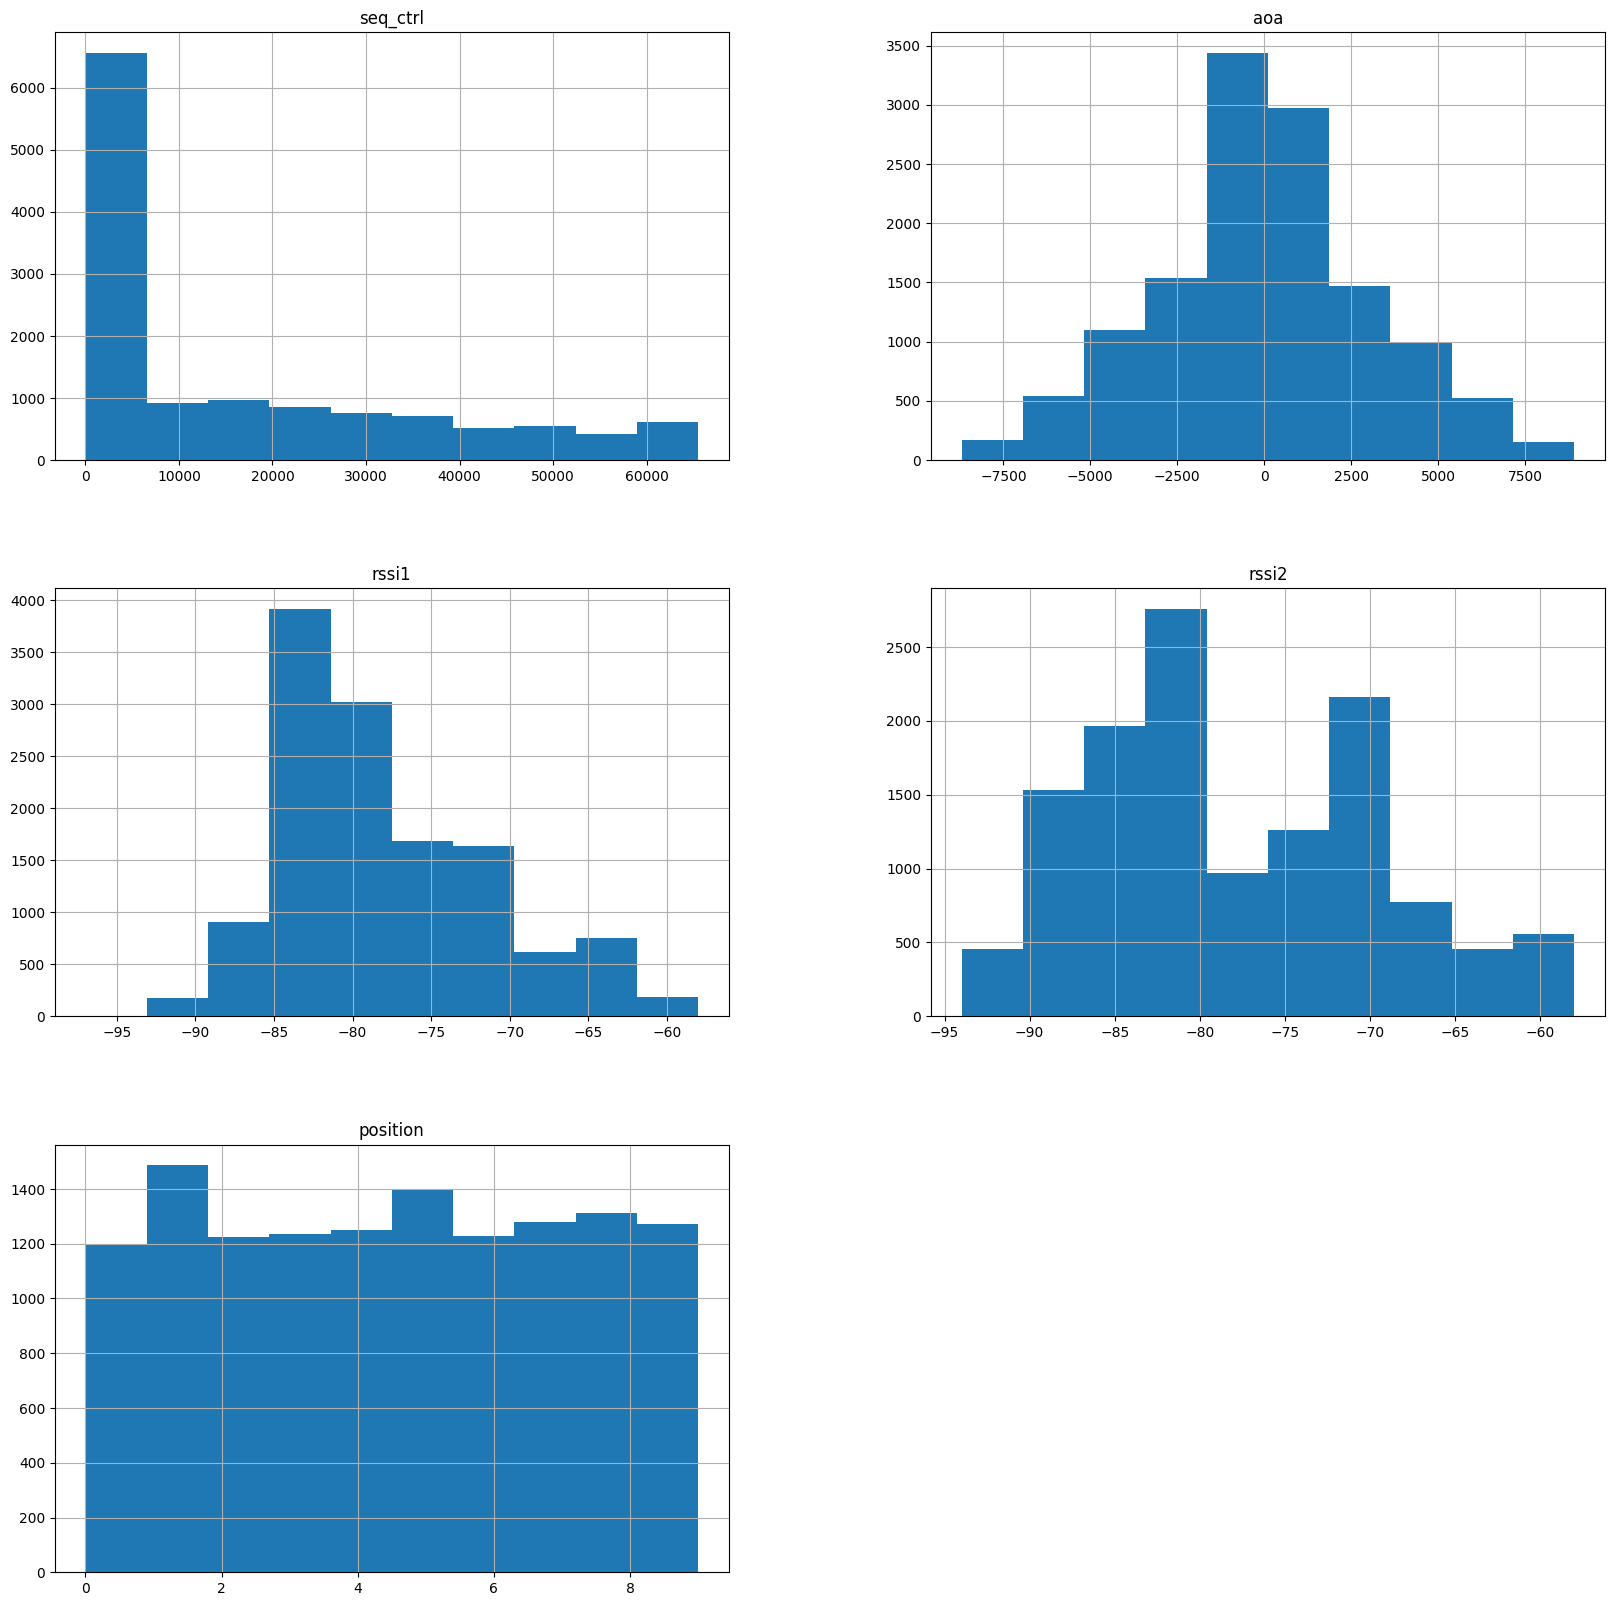

In [70]:
wifi_non_raw_csi = wifi[['seq_ctrl', 'aoa', 'rssi1', 'rssi2', 'position']]
wifi_non_raw_csi.hist(figsize=(20,20))

In [71]:
wifi_non_raw_csi.describe()

,seq_ctrl,aoa,rssi1,rssi2,position
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,16008.409683,15.017070,-78.052297,-77.951505,4.493094
std,19829.509485,3087.311342,6.804665,8.349372,2.871060
min,0.000000,-8703.000000,-97.000000,-94.000000,0.000000
25%,0.000000,-1751.000000,-83.000000,-84.000000,2.000000
50%,5464.000000,-30.000000,-80.000000,-80.000000,5.000000
75%,29424.000000,1798.000000,-74.000000,-71.000000,7.000000
max,65520.000000,8915.000000,-58.000000,-58.000000,9.000000


There are no strange values that could be considered as missing values or outliers.


## Class Balance Analysis

position
1    1488
5    1397
8    1312
7    1278
9    1273
4    1249
3    1237
6    1230
2    1224
0    1200
Name: count, dtype: int64


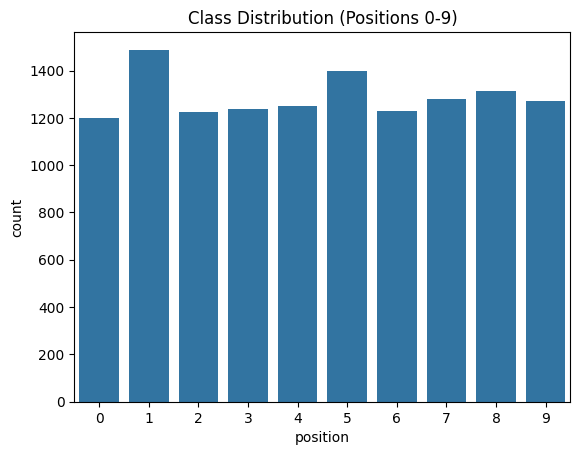

In [72]:
import seaborn as sns
position_counts = wifi["position"].value_counts()
print(position_counts)
# Plot bar chart of class distribution
sns.countplot(x=wifi["position"])
plt.title("Class Distribution (Positions 0-9)")
plt.show()

Our dataset is well-balanced. 
However, we will still use balanced metrics and StratifiedKFolding to ensure the folds are well-balanced too.


## FINDING OUTLIERS

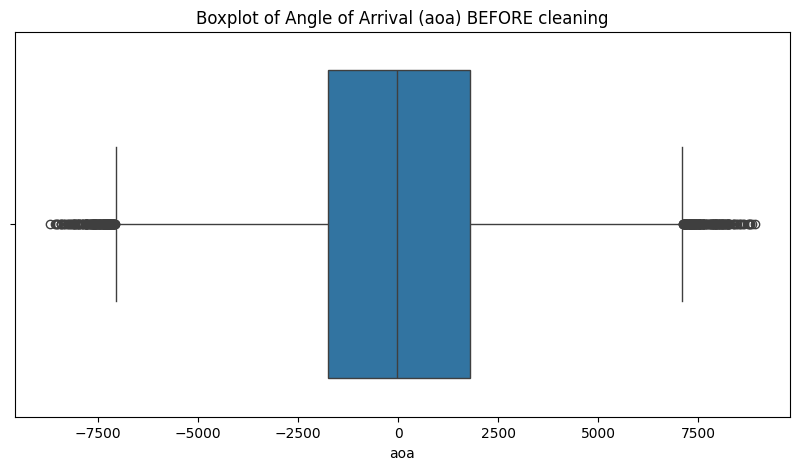

Realistic outliers in AOA: 303


In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot the raw data first so you can see the outliers with your own eyes
plt.figure(figsize=(10, 5))
sns.boxplot(x=wifi['aoa'])
plt.title("Boxplot of Angle of Arrival (aoa) BEFORE cleaning")
plt.show()

# 2. Use simple IQR to find realistic outliers (e.g., people walking in front of the antenna)
Q1 = wifi['aoa'].quantile(0.25)
Q3 = wifi['aoa'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Count how many REAL outliers there are (It should be a few hundred, NOT 12,000!)
outliers = wifi[(wifi['aoa'] < lower_bound) | (wifi['aoa'] > upper_bound)]
print(f"Realistic outliers in AOA: {len(outliers)}")


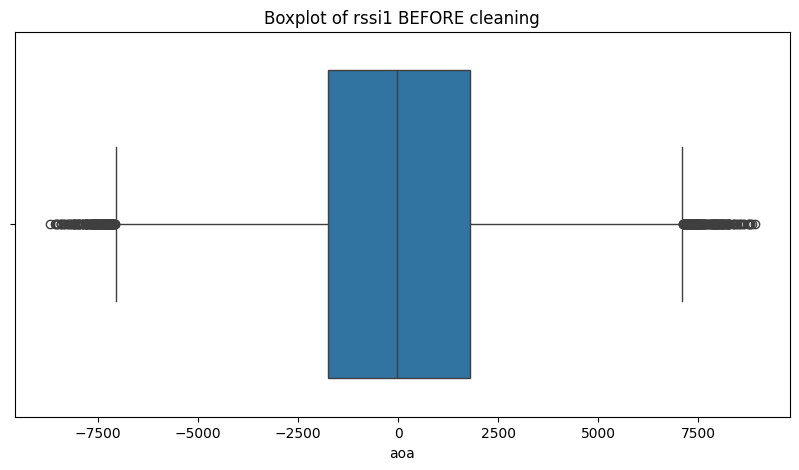

Realistic outliers in rssi1: 49


In [74]:

# 1. Plot the raw data first so you can see the outliers with your own eyes
plt.figure(figsize=(10, 5))
sns.boxplot(x=wifi['aoa'])
plt.title("Boxplot of rssi1 BEFORE cleaning")
plt.show()

# 2. Use simple IQR to find realistic outliers (e.g., people walking in front of the antenna)
Q1 = wifi['rssi1'].quantile(0.25)
Q3 = wifi['rssi1'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Count how many REAL outliers there are (It should be a few hundred, NOT 12,000!)
outliers = wifi[(wifi['rssi1'] < lower_bound) | (wifi['rssi1'] > upper_bound)]
print(f"Realistic outliers in rssi1: {len(outliers)}")


In [75]:
wifi['aoa'].describe()

count    12888.000000
mean        15.017070
std       3087.311342
min      -8703.000000
25%      -1751.000000
50%        -30.000000
75%       1798.000000
max       8915.000000
Name: aoa, dtype: float64

In [76]:
wifi['rssi1'].describe()

count    12888.000000
mean       -78.052297
std          6.804665
min        -97.000000
25%        -83.000000
50%        -80.000000
75%        -74.000000
max        -58.000000
Name: rssi1, dtype: float64

The aoa variable in the dataset is presented as a synthetic feature generated during postprocessing, intended to represent the estimated Angle of Arrival (AoA) derived from the phase difference between two receiving antennas. Under normal conditions, an AoA expressed in radians should be constrained within the physical range $[-\pi , \pi]$.

However, the statistical analysis of the column reveals values ranging approximately from –8700 to +8900, with a standard deviation exceeding 3000. This behavior is incompatible with any real angular magnitude and indicates that the feature does not reflect a physical AoA, but rather the result of an incomplete or incorrect computation. Such deviations typically occur when the phase difference between antennas is used directly without applying the essential signal processing steps, including:

phase unwrapping to correct ±$2\pi$ discontinuities,
removal of linear trends associated with Sampling Frequency Offset (SFO),
geometric calibration based on antenna spacing,
ambiguity resolution inherent to phase-based measurements,
normalization to the physical angular range.

When these steps are not applied, the accumulated phase may incorporate multiple $2\pi$ cycles, generating numerically large values with no physical interpretation. Consequently, the original aoa feature does not represent a real angle, but rather a highly noisy numerical residual.

Furthermore, this lack of consistency causes aoa to exhibit a distribution completely misaligned with the rest of the dataset variables, including a large number of extreme values. Incorporating it into the model could distort feature scaling, introduce noise, and degrade the performance of the learning algorithms.

For these reasons, the original aoa feature was removed from the dataset. This decision ensures that the model operates exclusively on consistent and physically interpretable variables.

Subsequently, a recomputed AoA was incorporated using the I/Q components from the two antennas, applying phase unwrapping, trend correction, and relative phase estimation. This new AoA, represented through its sine and cosine components, is stable, physically coherent, and suitable for modeling.

La variable rssi1 representa la potència del senyal rebut (RSSI) en dBm. Tot i que l’IQR detecta 49 valors com a “outliers”, aquests no corresponen a anomalies reals, sinó a variabilitat física normal del canal WiFi. El rang observat (–97 dBm a –58 dBm) és totalment coherent amb valors típics de senyal en entorns indoor. Per aquest motiu, no s’han eliminat ni capat aquests valors, ja que formen part de la dinàmica natural del senyal i poden aportar informació rellevant al model.


### IQR

In [77]:
for column in wifi_non_raw_csi.columns:
    print(f"Column: {column}")

    Q1 = wifi[column].quantile(0.25)
    Q3 = wifi[column].quantile(0.75)
    IQR = Q3 - Q1

    Q1, Q3, IQR
    (np.float64(1116.25), np.float64(1691.5), np.float64(575.25))
    small_outliers = wifi[column] < (Q1 - 1.5 * IQR)
    big_outliers = wifi[column] > (Q3 + 1.5 * IQR)

    print(f"There are {sum(small_outliers)} 'small' outliers and {sum(big_outliers)} 'big' outliers.")

Column: seq_ctrl
There are 0 'small' outliers and 0 'big' outliers.
Column: aoa
There are 146 'small' outliers and 157 'big' outliers.
Column: rssi1
There are 1 'small' outliers and 48 'big' outliers.
Column: rssi2
There are 0 'small' outliers and 0 'big' outliers.
Column: position
There are 0 'small' outliers and 0 'big' outliers.


### Model based

In [78]:
lof = LocalOutlierFactor(n_neighbors=20)

for column in wifi_non_raw_csi.columns:
    print(f"\n=== COLUMN: {column} ===")

    values = wifi[column].values.reshape(-1, 1)
    preds = lof.fit_predict(values)

    counts = Counter(preds)

    n_outliers = counts[-1]
    n_inliers = counts[1]

    print(f"Outliers: {n_outliers}")
    print(f"Outlier ratio: {n_outliers / len(values):.4f}")


=== COLUMN: seq_ctrl ===


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Outliers: 333
Outlier ratio: 0.0258

=== COLUMN: aoa ===
Outliers: 59
Outlier ratio: 0.0046

=== COLUMN: rssi1 ===
Outliers: 9
Outlier ratio: 0.0007

=== COLUMN: rssi2 ===
Outliers: 26
Outlier ratio: 0.0020

=== COLUMN: position ===
Outliers: 0
Outlier ratio: 0.0000


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


### TREATMENT OF MIXED DATA TYPES

All variables are numerical, so we don't have to worry about mixed data types.

## DERIVATION OF NEW VARIABLES - FEATURE EXTRACTION

In [79]:
import numpy as np
import pandas as pd
from scipy import stats

def extract_iq_pairs(df):
    """Extract I/Q pairs from raw CSI columns (antenna 1 and 2)."""
    I1_cols = [f'I{n}_1' for n in range(64)]
    Q1_cols = [f'Q{n}_1' for n in range(64)]
    I2_cols = [f'I{n}_2' for n in range(64)]
    Q2_cols = [f'Q{n}_2' for n in range(64)]
    
    IQ_ant1 = df[I1_cols].values + 1j * df[Q1_cols].values
    IQ_ant2 = df[I2_cols].values + 1j * df[Q2_cols].values
    return IQ_ant1, IQ_ant2

def compute_amplitude(IQ): return np.abs(IQ)
def compute_phase(IQ): return np.angle(IQ)
def compute_phase_unwrapped(phase): return np.unwrap(phase, axis=1)

def sanitize_phase(phase_unwr):
    """Remove linear SFO trend from unwrapped phase."""
    x = np.arange(phase_unwr.shape[1])
    sanitized = np.zeros_like(phase_unwr)
    for i in range(phase_unwr.shape[0]):
        m, c = np.polyfit(x, phase_unwr[i], 1)
        sanitized[i] = phase_unwr[i] - (m * x + c)
    return sanitized

def compute_frequency_domain_features(data):
    fft_result = np.fft.fft(data, axis=1)
    fft_mag = np.abs(fft_result)
    
    features = {}
    features['spectral_energy'] = np.sum(fft_mag ** 2, axis=1)
    
    safe_fft_mag = fft_mag + 1e-10
    features['spectral_entropy'] = stats.entropy(safe_fft_mag, axis=1)
    
    bins = np.arange(fft_mag.shape[1])
    features['spectral_centroid'] = np.sum(fft_mag * bins, axis=1) / np.sum(safe_fft_mag, axis=1)
    return features

def compute_antenna_correlation(IQ_ant1, IQ_ant2):
    correlations = []
    for i in range(len(IQ_ant1)):
        corr = np.corrcoef(np.abs(IQ_ant1[i]), np.abs(IQ_ant2[i]))[0, 1]
        correlations.append(corr)
    return np.nan_to_num(correlations, nan=0.0)

def compute_phase_consistency(phase_ant1, phase_ant2):
    phase_diff = np.angle(np.exp(1j * (phase_ant1 - phase_ant2)))
    cos_mean = np.mean(np.cos(phase_diff), axis=1)
    sin_mean = np.mean(np.sin(phase_diff), axis=1)
    return np.sqrt(cos_mean ** 2 + sin_mean ** 2)

def extract_all_features(df):
    IQ_ant1, IQ_ant2 = extract_iq_pairs(df)
    features = {}    

    # 1. Amplitude & Phase
    amp_ant1 = compute_amplitude(IQ_ant1)
    amp_ant2 = compute_amplitude(IQ_ant2)
    phase_ant1 = compute_phase(IQ_ant1)
    phase_ant2 = compute_phase(IQ_ant2)
    
    # 2. Phase Sanitization
    phase_unwr_ant1 = compute_phase_unwrapped(phase_ant1)
    phase_unwr_ant2 = compute_phase_unwrapped(phase_ant2)
    sanitized_p1 = sanitize_phase(phase_unwr_ant1)
    sanitized_p2 = sanitize_phase(phase_unwr_ant2)
    rel_phase = sanitized_p1 - sanitized_p2

    # 3. Frequency Domain
    for k, v in compute_frequency_domain_features(amp_ant1).items():
        features[f'freq_ant1_{k}'] = v
    for k, v in compute_frequency_domain_features(amp_ant2).items():
        features[f'freq_ant2_{k}'] = v
    
    # 4. Cross-Antenna
    features['antenna_correlation'] = compute_antenna_correlation(IQ_ant1, IQ_ant2)
    features['phase_consistency'] = compute_phase_consistency(phase_ant1, phase_ant2)
    
    # 5. Amplitude Stats
    features['amp_ant1_mean'] = np.mean(amp_ant1, axis=1)
    features['amp_ant1_std'] = np.std(amp_ant1, axis=1)
    features['amp_ant2_mean'] = np.mean(amp_ant2, axis=1)
    features['amp_ant2_std'] = np.std(amp_ant2, axis=1)
    
    # 6. Relative Phase Stats
    features['rel_phase_mean'] = np.mean(rel_phase, axis=1)
    features['rel_phase_std'] = np.std(rel_phase, axis=1)

    # 7. NEW: Recomputed AoA (physically meaningful)
    aoa_est = np.mean(rel_phase, axis=1)          # angle proxy
    features['aoa_est'] = aoa_est
    # features['aoa_sin'] = np.sin(aoa_est)
    # features['aoa_cos'] = np.cos(aoa_est)

    # 8. Build DataFrame
    df_features = pd.DataFrame(features)
    return df_features

# Execute
wifi_features = extract_all_features(wifi)
print(f"Extracted {wifi_features.shape[1]} features successfully.")

Extracted 15 features successfully.


In [80]:
wifi_features = extract_all_features(wifi)
print(f"Extracted {wifi_features.shape[1]-1} features successfully.")
wifi_features.head()

Extracted 14 features successfully.


,freq_ant1_spectral_energy,freq_ant1_spectral_entropy,freq_ant1_spectral_centroid,freq_ant2_spectral_energy,freq_ant2_spectral_entropy,freq_ant2_spectral_centroid,antenna_correlation,phase_consistency,amp_ant1_mean,amp_ant1_std,amp_ant2_mean,amp_ant2_std,rel_phase_mean,rel_phase_std,aoa_est
0,622912.0,3.293113,23.923196,551104.0,3.220061,23.990110,0.457565,0.209775,10.500734,6.466274,9.595087,6.517759,-2.671474e-16,1.230063,-2.671474e-16
1,687616.0,3.506048,24.893213,424768.0,3.339236,24.835525,0.397510,0.678378,11.039852,6.782084,8.080124,6.197960,-1.380840e-15,2.020773,-1.380840e-15
2,524544.0,3.431066,24.533911,545728.0,3.397970,24.216590,0.766544,0.916925,9.683494,5.855974,9.918375,5.904254,1.162265e-16,0.385168,1.162265e-16
3,634496.0,3.288601,24.905849,712064.0,3.242197,23.492324,0.100826,0.645218,9.683126,7.819419,11.229586,6.909425,1.561251e-16,0.902391,1.561251e-16
4,524672.0,3.355711,25.304652,509568.0,3.253057,23.216126,0.468697,0.682586,8.693792,7.246498,9.798835,5.328141,1.318390e-16,1.091202,1.318390e-16


In [81]:
wifi_features.describe()

,freq_ant1_spectral_energy,freq_ant1_spectral_entropy,freq_ant1_spectral_centroid,freq_ant2_spectral_energy,freq_ant2_spectral_entropy,freq_ant2_spectral_centroid,antenna_correlation,phase_consistency,amp_ant1_mean,amp_ant1_std,amp_ant2_mean,amp_ant2_std,rel_phase_mean,rel_phase_std,aoa_est
count,1.288800e+04,12888.000000,12888.000000,1.288800e+04,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,1.288800e+04,12888.000000,1.288800e+04
mean,6.031116e+05,3.263817,23.744095,5.921104e+05,3.302459,23.777349,0.752104,0.703543,10.301629,6.309942,10.293085,6.114690,3.450742e-19,1.038509,3.450742e-19
std,7.386938e+04,0.087279,0.724854,8.676549e+04,0.121302,0.939139,0.191359,0.197347,0.825414,0.789873,0.922406,0.608618,5.520785e-16,0.548482,5.520785e-16
min,5.907200e+04,2.948853,22.383519,9.369600e+04,3.042533,22.330213,-0.262451,0.011759,3.074768,2.228829,3.667012,3.070508,-4.496403e-15,0.048882,-4.496403e-15
25%,5.586560e+05,3.203939,23.093495,5.452000e+05,3.217094,23.049528,0.658564,0.594510,9.768812,5.705844,9.841451,5.714561,-2.116363e-16,0.610295,-2.116363e-16
50%,6.033920e+05,3.249042,23.702082,5.956480e+05,3.256008,23.460847,0.779056,0.712493,10.359086,6.116301,10.415830,6.026254,-1.734723e-18,1.027405,-1.734723e-18
75%,6.512640e+05,3.306873,24.278966,6.464640e+05,3.362220,24.240644,0.901709,0.865869,10.888689,6.842962,10.905638,6.415624,2.118531e-16,1.394412,2.118531e-16
max,1.026688e+06,3.722932,27.287473,1.251328e+06,3.777846,26.969244,0.996632,0.998675,13.175883,9.445326,14.299543,10.186853,3.788636e-15,5.015873,3.788636e-15


In [82]:
wifi = pd.concat([wifi.reset_index(drop=True),
                  wifi_features.reset_index(drop=True)], axis=1)

In [83]:
print(wifi.shape)
wifi.head()
wifi.describe()

(12888, 277)


,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,freq_ant2_spectral_centroid,antenna_correlation,phase_consistency,amp_ant1_mean,amp_ant1_std,amp_ant2_mean,amp_ant2_std,rel_phase_mean,rel_phase_std,aoa_est
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.0,12888.0,12888.000000,12888.000000,12888.000000,...,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,1.288800e+04,12888.000000,1.288800e+04
mean,6443.500000,16008.409683,15.017070,-78.052297,-77.951505,0.0,0.0,-0.406425,-0.477576,-0.499690,...,23.777349,0.752104,0.703543,10.301629,6.309942,10.293085,6.114690,3.450742e-19,1.038509,3.450742e-19
std,3720.589469,19829.509485,3087.311342,6.804665,8.349372,0.0,0.0,10.208896,10.122726,10.415635,...,0.939139,0.191359,0.197347,0.825414,0.789873,0.922406,0.608618,5.520785e-16,0.548482,5.520785e-16
min,0.000000,0.000000,-8703.000000,-97.000000,-94.000000,0.0,0.0,-25.000000,-26.000000,-24.000000,...,22.330213,-0.262451,0.011759,3.074768,2.228829,3.667012,3.070508,-4.496403e-15,0.048882,-4.496403e-15
25%,3221.750000,0.000000,-1751.000000,-83.000000,-84.000000,0.0,0.0,-10.000000,-10.000000,-10.000000,...,23.049528,0.658564,0.594510,9.768812,5.705844,9.841451,5.714561,-2.116363e-16,0.610295,-2.116363e-16
50%,6443.500000,5464.000000,-30.000000,-80.000000,-80.000000,0.0,0.0,0.000000,0.000000,0.000000,...,23.460847,0.779056,0.712493,10.359086,6.116301,10.415830,6.026254,-1.734723e-18,1.027405,-1.734723e-18
75%,9665.250000,29424.000000,1798.000000,-74.000000,-71.000000,0.0,0.0,9.000000,9.000000,9.000000,...,24.240644,0.901709,0.865869,10.888689,6.842962,10.905638,6.415624,2.118531e-16,1.394412,2.118531e-16
max,12887.000000,65520.000000,8915.000000,-58.000000,-58.000000,0.0,0.0,25.000000,25.000000,23.000000,...,26.969244,0.996632,0.998675,13.175883,9.445326,14.299543,10.186853,3.788636e-15,5.015873,3.788636e-15


We delete all columns were all values are 0.0 (do not app)

In [84]:
const_col = [col for col in wifi.columns if wifi[col].nunique() <= 1]

print(f"Columnas eliminadas: {const_col}")
wifi.drop(columns=const_col, inplace=True)
print(wifi.shape)

Columnas eliminadas: ['I0_1', 'Q0_1', 'I27_1', 'Q27_1', 'I28_1', 'Q28_1', 'I29_1', 'Q29_1', 'I30_1', 'Q30_1', 'I31_1', 'Q31_1', 'I32_1', 'Q32_1', 'I33_1', 'Q33_1', 'I34_1', 'Q34_1', 'I35_1', 'Q35_1', 'I36_1', 'Q36_1', 'I37_1', 'Q37_1', 'I0_2', 'Q0_2', 'I27_2', 'Q27_2', 'I28_2', 'Q28_2', 'I29_2', 'Q29_2', 'I30_2', 'Q30_2', 'I31_2', 'Q31_2', 'I32_2', 'Q32_2', 'I33_2', 'Q33_2', 'I34_2', 'Q34_2', 'I35_2', 'Q35_2', 'I36_2', 'Q36_2', 'I37_2', 'Q37_2']
(12888, 229)


LETS CHECK NEW ESTIMATED AOA

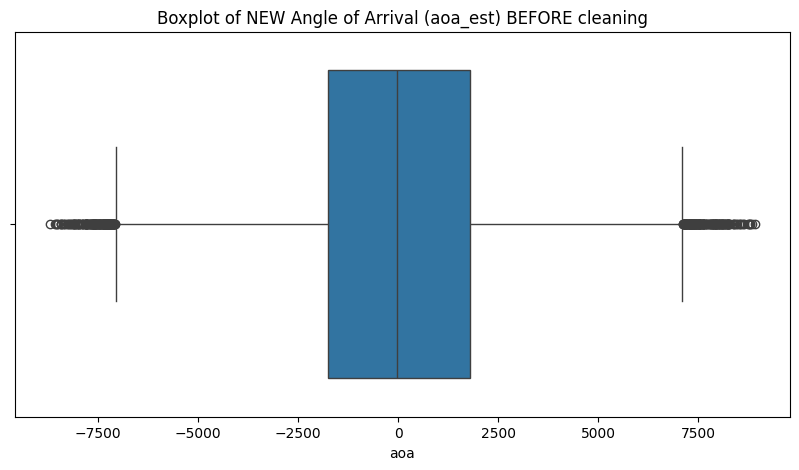

Realistic outliers in AOA_est: 157


In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot the raw data first so you can see the outliers with your own eyes
plt.figure(figsize=(10, 5))
sns.boxplot(x=wifi['aoa'])
plt.title("Boxplot of NEW Angle of Arrival (aoa_est) BEFORE cleaning")
plt.show()

# 2. Use simple IQR to find realistic outliers (e.g., people walking in front of the antenna)
Q1 = wifi['aoa'].quantile(0.25)
Q3 = wifi['aoa'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Count how many REAL outliers there are (It should be a few hundred, NOT 12,000!)
outliers = wifi[(wifi['aoa_est'] < lower_bound) | (wifi['aoa'] > upper_bound)]
print(f"Realistic outliers in AOA_est: {len(outliers)}")


In [86]:
wifi['aoa_est'].describe()

count    1.288800e+04
mean     3.450742e-19
std      5.520785e-16
min     -4.496403e-15
25%     -2.116363e-16
50%     -1.734723e-18
75%      2.118531e-16
max      3.788636e-15
Name: aoa_est, dtype: float64

In [87]:
wifi['aoa'].describe()

count    12888.000000
mean        15.017070
std       3087.311342
min      -8703.000000
25%      -1751.000000
50%        -30.000000
75%       1798.000000
max       8915.000000
Name: aoa, dtype: float64

Let's plot the features:

# FINAL DATASET

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from pyexpat import features
from scipy import stats
import os

# extra imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

## LOADING THE DATA

In [89]:
wifi = pd.read_csv('../data/raw/train_nt.csv', header=0, delimiter=';')
X_test = pd.read_csv('../data/raw/test_nolabels_nt.csv', header=0, delimiter=';')

print(f"Dataset shape: {wifi.shape}")
print(f"Missing values: {wifi.isnull().sum().sum()}")

Dataset shape: (12888, 262)
Missing values: 0


## Clean known Issues

### 1. Columns that don't provide information

In [90]:
columns_no_info = ['seq_ctrl', 'aoa', 'ID']

### 2. Constant columns

In [91]:
const_cols = [col for col in wifi.columns if wifi[col].nunique() <= 1]

In [92]:
columns_to_remove = columns_no_info + const_cols
print(columns_to_remove)

['seq_ctrl', 'aoa', 'ID', 'I0_1', 'Q0_1', 'I27_1', 'Q27_1', 'I28_1', 'Q28_1', 'I29_1', 'Q29_1', 'I30_1', 'Q30_1', 'I31_1', 'Q31_1', 'I32_1', 'Q32_1', 'I33_1', 'Q33_1', 'I34_1', 'Q34_1', 'I35_1', 'Q35_1', 'I36_1', 'Q36_1', 'I37_1', 'Q37_1', 'I0_2', 'Q0_2', 'I27_2', 'Q27_2', 'I28_2', 'Q28_2', 'I29_2', 'Q29_2', 'I30_2', 'Q30_2', 'I31_2', 'Q31_2', 'I32_2', 'Q32_2', 'I33_2', 'Q33_2', 'I34_2', 'Q34_2', 'I35_2', 'Q35_2', 'I36_2', 'Q36_2', 'I37_2', 'Q37_2']


In [93]:
def remove_columns(df, cols: list['str']) -> None:
    df.drop(columns=cols, inplace=True, errors = 'ignore')
    print(f"Removed columns: {cols}")


## Feature Engineering

In [94]:
def extract_iq_pairs(df):
    I1 = [f'I{n}_1' for n in range(64)]
    Q1 = [f'Q{n}_1' for n in range(64)]
    I2 = [f'I{n}_2' for n in range(64)]
    Q2 = [f'Q{n}_2' for n in range(64)]
    IQ1 = df[I1].values + 1j * df[Q1].values
    IQ2 = df[I2].values + 1j * df[Q2].values
    return IQ1, IQ2

def compute_amplitude(IQ):
    return np.abs(IQ)

def compute_phase(IQ):
    return np.angle(IQ)

def compute_phase_unwrapped(phase):
    return np.unwrap(phase, axis=1)

def sanitize_phase(phase_unwr):
    x = np.arange(phase_unwr.shape[1])
    sanitized = np.zeros_like(phase_unwr)
    for i in range(phase_unwr.shape[0]):
        m, c = np.polyfit(x, phase_unwr[i], 1)
        sanitized[i] = phase_unwr[i] - (m * x + c)
    return sanitized

def compute_frequency_domain_features(data):
    fft_result = np.fft.fft(data, axis=1)
    fft_mag = np.abs(fft_result)
    safe = fft_mag + 1e-10
    return {
        'spectral_energy': np.sum(fft_mag**2, axis=1),
        'spectral_entropy': stats.entropy(safe, axis=1),
        'spectral_centroid': np.sum(fft_mag * np.arange(fft_mag.shape[1]), axis=1) / np.sum(safe, axis=1)
    }

def compute_antenna_correlation(IQ1, IQ2):
    corr = []
    for i in range(len(IQ1)):
        c = np.corrcoef(np.abs(IQ1[i]), np.abs(IQ2[i]))[0, 1]
        corr.append(c)
    return np.nan_to_num(corr)

def compute_phase_consistency(p1, p2):
    diff = np.angle(np.exp(1j * (p1 - p2)))
    cos_m = np.mean(np.cos(diff), axis=1)
    sin_m = np.mean(np.sin(diff), axis=1)
    return np.sqrt(cos_m**2 + sin_m**2)

In [95]:
def extract_all_features(df):
    IQ1, IQ2 = extract_iq_pairs(df)

    amp1 = compute_amplitude(IQ1)
    amp2 = compute_amplitude(IQ2)
    ph1 = compute_phase(IQ1)
    ph2 = compute_phase(IQ2)

    ph1_un = compute_phase_unwrapped(ph1)
    ph2_un = compute_phase_unwrapped(ph2)

    san1 = sanitize_phase(ph1_un)
    san2 = sanitize_phase(ph2_un)

    rel_phase = san1 - san2

    features = {}

    # Frequency domain
    for k, v in compute_frequency_domain_features(amp1).items():
        features[f'freq_ant1_{k}'] = v
    for k, v in compute_frequency_domain_features(amp2).items():
        features[f'freq_ant2_{k}'] = v

    # Cross-antenna
    features['antenna_correlation'] = compute_antenna_correlation(IQ1, IQ2)
    features['phase_consistency'] = compute_phase_consistency(ph1, ph2)

    # Stats
    features['amp_ant1_mean'] = amp1.mean(axis=1)
    features['amp_ant1_std'] = amp1.std(axis=1)
    features['amp_ant2_mean'] = amp2.mean(axis=1)
    features['amp_ant2_std'] = amp2.std(axis=1)

    features['rel_phase_mean'] = rel_phase.mean(axis=1)
    features['rel_phase_std'] = rel_phase.std(axis=1)

    # AoA proxy
    aoa_est = rel_phase.mean(axis=1)
    features['aoa_sin'] = np.sin(aoa_est)
    features['aoa_cos'] = np.cos(aoa_est)

    return pd.DataFrame(features)

In [96]:
def build_dataset(df_raw):
    df_raw = df_raw.reset_index(drop=True)
    
    df_features = extract_all_features(df_raw)
    
    mag_cols = {}
    for antena in [1, 2]:
        for n in range(64):
            i_col = f"I{n}_{antena}"
            q_col = f"Q{n}_{antena}"
            mag_col = f"mag{n}_{antena}"
            mag_cols[mag_col] = np.sqrt(df_raw[i_col]**2 + df_raw[q_col]**2)
            
    df_magnitudes = pd.DataFrame(mag_cols)
    
    df_rssi = df_raw[['rssi1', 'rssi2']]
    
    X_clean = pd.concat([df_features, df_magnitudes, df_rssi], axis=1)
    
    return X_clean

In [97]:
X = wifi.drop(columns=['position'])
y = wifi['position']

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train = build_dataset(X_train_raw)
X_val   = build_dataset(X_val_raw)
X_test  = build_dataset(X_test)


## Class Balance Analysis

position
1    1190
5    1118
8    1050
7    1022
9    1018
4     999
3     990
6     984
2     979
0     960
Name: count, dtype: int64


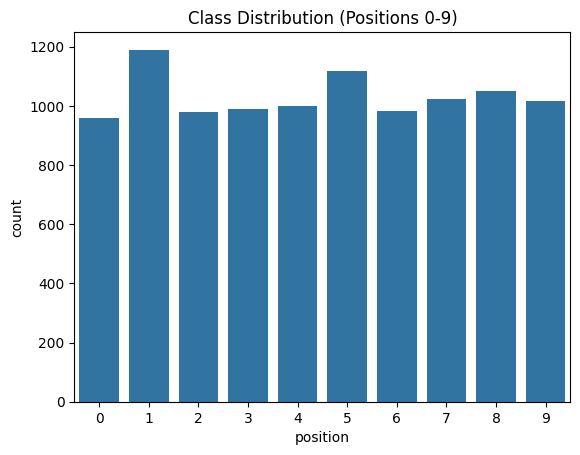

In [98]:
import seaborn as sns
position_counts = y_train.value_counts()
print(position_counts)
# Plot bar chart of class distribution
sns.countplot(x=y_train)
plt.title("Class Distribution (Positions 0-9)")
plt.show()

## Correlation Analysis

    freq_ant1_spectral_energy  freq_ant1_spectral_entropy  \
0                    376832.0                    3.313289   
1                    653440.0                    3.202104   
2                    687552.0                    3.245408   
3                    625728.0                    3.200095   
4                    687680.0                    3.292742   
..                        ...                         ...   
95                   726400.0                    3.134612   
96                   691136.0                    3.247303   
97                   689088.0                    3.235753   
98                   665536.0                    3.185897   
99                   630272.0                    3.194539   

    freq_ant1_spectral_centroid  freq_ant2_spectral_energy  \
0                     23.893893                   311552.0   
1                     23.229903                   558208.0   
2                     23.213747                   601728.0   
3                  

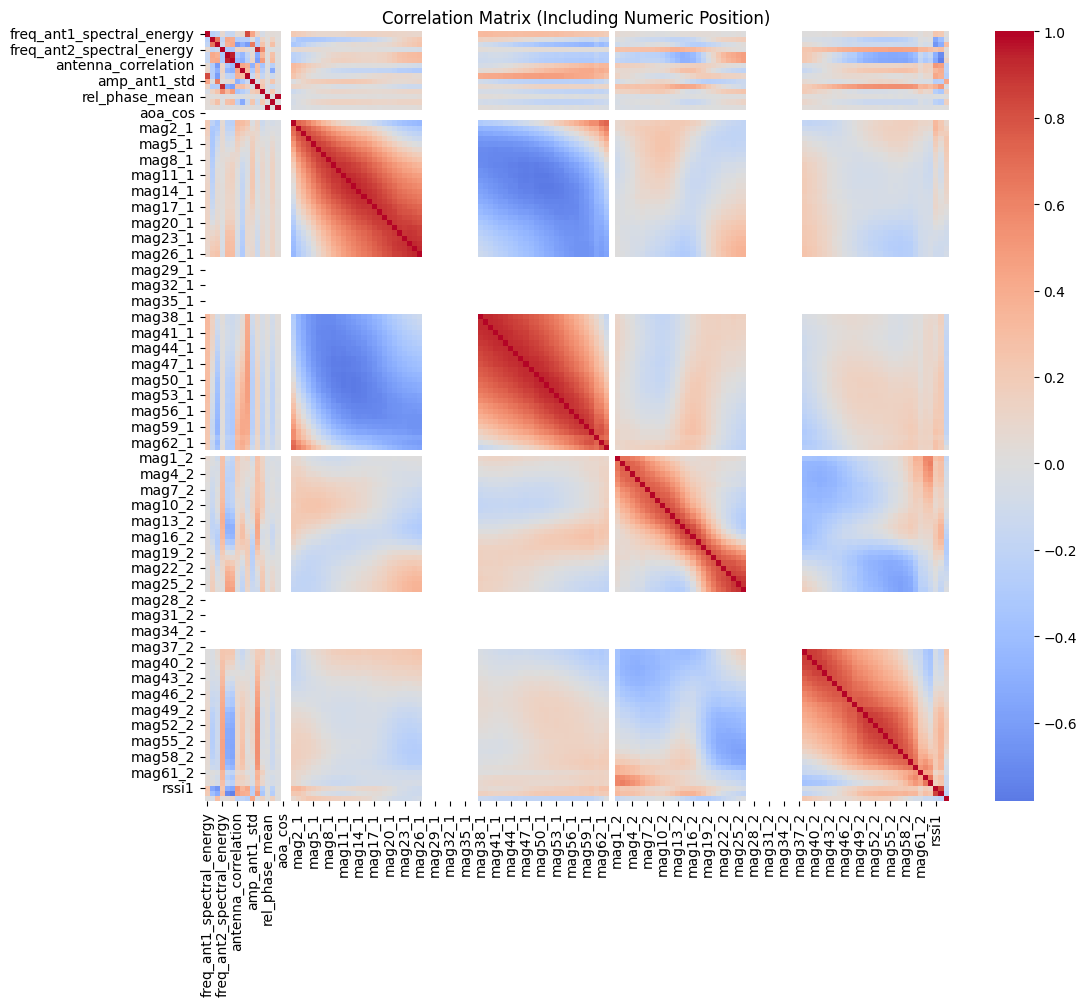

In [111]:
X_train_df = pd.DataFrame(X_train).reset_index(drop=True)
y_train_aligned = y_train.reset_index(drop=True)

full_train_data = pd.concat([X_train_df, y_train_aligned], axis=1)

print(full_train_data.head(100))
print(full_train_data['position'].dtype)
plot_data = full_train_data.copy()


plot_data['position'] = pd.factorize(plot_data['position'])[0]

corr_matrix = plot_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix (Including Numeric Position)")
plt.show()

Top correlated

In [100]:
print("Top correlated feature pairs")
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlation = upper_triangle.stack()
correlation = correlation.reindex(correlation.abs().sort_values(ascending=False).index)
print(correlation.head(20))

Top correlated feature pairs
rel_phase_mean              aoa_sin                        1.000000
freq_ant2_spectral_entropy  freq_ant2_spectral_centroid    0.945436
mag50_1                     mag51_1                        0.940243
mag49_1                     mag50_1                        0.938507
mag40_1                     mag41_1                        0.933224
mag38_1                     mag39_1                        0.931983
freq_ant2_spectral_energy   amp_ant2_mean                  0.930266
mag25_1                     mag26_1                        0.930116
mag46_1                     mag47_1                        0.929283
mag13_1                     mag14_1                        0.929156
mag51_1                     mag52_1                        0.928559
mag39_1                     mag40_1                        0.928194
mag41_1                     mag42_1                        0.927299
mag38_1                     mag40_1                        0.926822
mag53_1            

Top correlated features with target

In [101]:
print("Top correlated features with target")
correlation_with_target = X_train.corrwith(y_train).sort_values(ascending=False)
print(correlation_with_target.head(20))

Top correlated features with target


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


mag8_2                         0.019983
mag9_2                         0.015724
mag5_2                         0.015240
mag4_1                         0.013898
mag6_2                         0.013883
freq_ant2_spectral_centroid    0.013345
mag7_1                         0.013163
mag22_2                        0.012114
freq_ant2_spectral_entropy     0.011869
mag21_2                        0.011770
mag6_1                         0.011612
mag63_1                        0.010897
mag62_1                        0.010727
antenna_correlation            0.010227
mag3_1                         0.009001
mag25_2                        0.008934
mag1_1                         0.008610
mag13_1                        0.008303
mag26_2                        0.008288
mag7_2                         0.008194
dtype: float64


In [102]:
print(corr_matrix)

                             freq_ant1_spectral_energy  \
freq_ant1_spectral_energy                     1.000000   
freq_ant1_spectral_entropy                   -0.243932   
freq_ant1_spectral_centroid                  -0.187440   
freq_ant2_spectral_energy                     0.078233   
freq_ant2_spectral_entropy                   -0.145809   
...                                                ...   
mag62_2                                       0.047556   
mag63_2                                       0.036356   
rssi1                                         0.239307   
rssi2                                         0.205625   
position                                     -0.013457   

                             freq_ant1_spectral_entropy  \
freq_ant1_spectral_energy                     -0.243932   
freq_ant1_spectral_entropy                     1.000000   
freq_ant1_spectral_centroid                    0.659292   
freq_ant2_spectral_energy                     -0.186876   
freq_ant

## VIF

In [112]:
# Variance Inflation Factor (VIF) for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
X_vif = X_train.select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan).dropna(axis=1)
X_vif = X_vif.loc[:, X_vif.nunique() > 1]  # VIF is undefined for constant columns
X_vif_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_vif),
    columns=X_vif.columns,
    index=X_vif.index
)
vif = pd.DataFrame({
    "feature": X_vif_scaled.columns,
    "VIF": [variance_inflation_factor(X_vif_scaled.values, i) for i in range(X_vif_scaled.shape[1])]
})
vif = vif.sort_values("VIF", ascending=False)
print(vif.head(20))


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


           feature  VIF
8    amp_ant1_mean  inf
17          mag3_1  inf
18          mag4_1  inf
19          mag5_1  inf
16          mag2_1  inf
14         aoa_sin  inf
15          mag1_1  inf
12  rel_phase_mean  inf
10   amp_ant2_mean  inf
21          mag7_1  inf
22          mag8_1  inf
23          mag9_1  inf
20          mag6_1  inf
24         mag10_1  inf
35         mag21_1  inf
34         mag20_1  inf
33         mag19_1  inf
32         mag18_1  inf
31         mag17_1  inf
30         mag16_1  inf


##  Statistical Separability

                         feature      f_score  p_value
145                        rssi2  5255.916942      0.0
144                        rssi1  3727.417027      0.0
5    freq_ant2_spectral_centroid  2368.171370      0.0
4     freq_ant2_spectral_entropy  1872.451998      0.0
106                      mag26_2  1104.229030      0.0
105                      mag25_2  1036.059721      0.0
133                      mag53_2   928.696988      0.0
134                      mag54_2   876.270949      0.0
132                      mag52_2   876.040761      0.0
104                      mag24_2   855.369412      0.0
135                      mag55_2   849.847478      0.0
25                        mag9_1   806.366929      0.0
131                      mag51_2   805.588671      0.0
136                      mag56_2   783.195266      0.0
66                       mag50_1   783.148374      0.0


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 15  16  43  44  45  46  47  48  49  50  51  52  53  80 107 108 109 110
 111 112 113 114 115 116 117] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


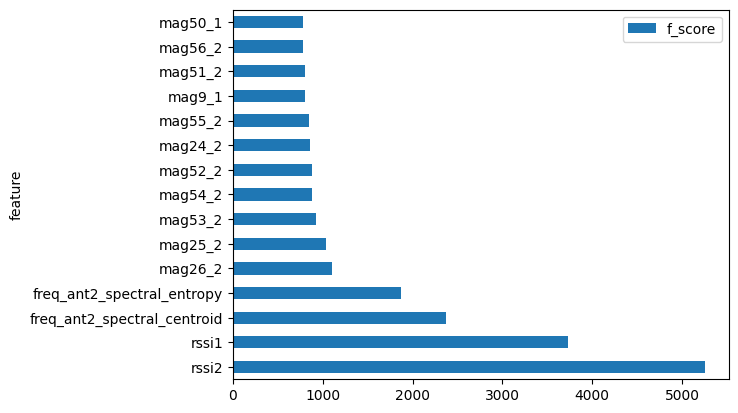

In [104]:
# F-score or ANOVA to show which features best discriminate positions
from sklearn.feature_selection import f_classif
f_scores, p_values = f_classif(X_train, y_train)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)
print(feature_importance.head(15))
# Plot top features
feature_importance.head(15).plot(x='feature', y='f_score', kind='barh')
plt.show()

## Antenna Comparison

In [105]:
# Are the two antennas providing complementary information?
ant1_cols = [col for col in X_train.columns if 'ant1' in col.lower()]
ant2_cols = [col for col in X_train.columns if 'ant2' in col.lower()]

# Correlation between corresponding antenna features
for a1, a2 in zip(ant1_cols[:5], ant2_cols[:5]):
    corr = X_train[a1].corr(X_train[a2])
    print(f"{a1} vs {a2}: {corr:.3f}")

freq_ant1_spectral_energy vs freq_ant2_spectral_energy: 0.078
freq_ant1_spectral_entropy vs freq_ant2_spectral_entropy: 0.415
freq_ant1_spectral_centroid vs freq_ant2_spectral_centroid: 0.416
amp_ant1_mean vs amp_ant2_mean: 0.163
amp_ant1_std vs amp_ant2_std: 0.172


## RSSI Analysis by Distance

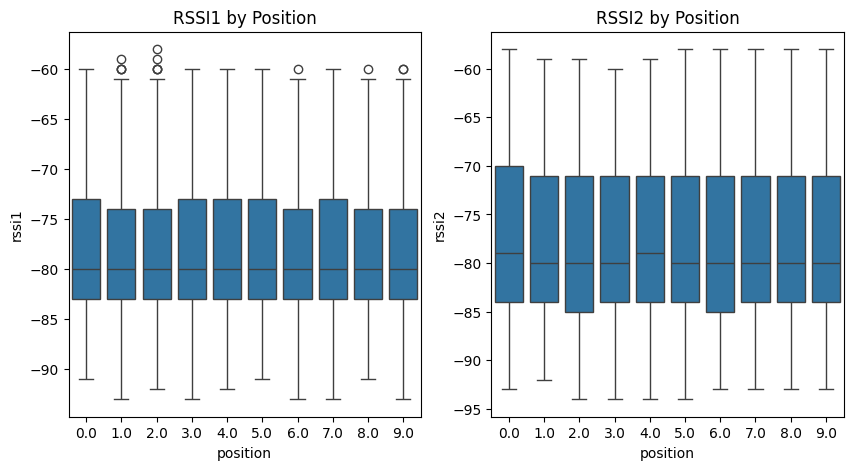

RSSI1 range by position:
          min  max       mean       std
position                               
0.0       -91  -60 -77.796935  7.045587
1.0       -93  -59 -78.209110  6.805801
2.0       -92  -58 -78.189189  6.827136
3.0       -93  -60 -78.076060  6.776286
4.0       -92  -60 -77.736444  6.882117
5.0       -91  -60 -77.761957  7.016913
6.0       -93  -60 -78.225931  6.443769
7.0       -93  -60 -77.929009  6.878843
8.0       -91  -60 -78.389024  6.606034
9.0       -93  -60 -78.185232  6.813537


In [106]:
# Given you have 2m and 5m distances per position
# Do RSSI values significantly differ? (If you can infer distance from data)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=y_train, y=X_train['rssi1'])
plt.title('RSSI1 by Position')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_train, y=X_train['rssi2'])
plt.title('RSSI2 by Position')
plt.show()

# Statistics
print(f"RSSI1 range by position:")
print(X_train.groupby(y_train)['rssi1'].agg(['min', 'max', 'mean', 'std']))

## Visualization

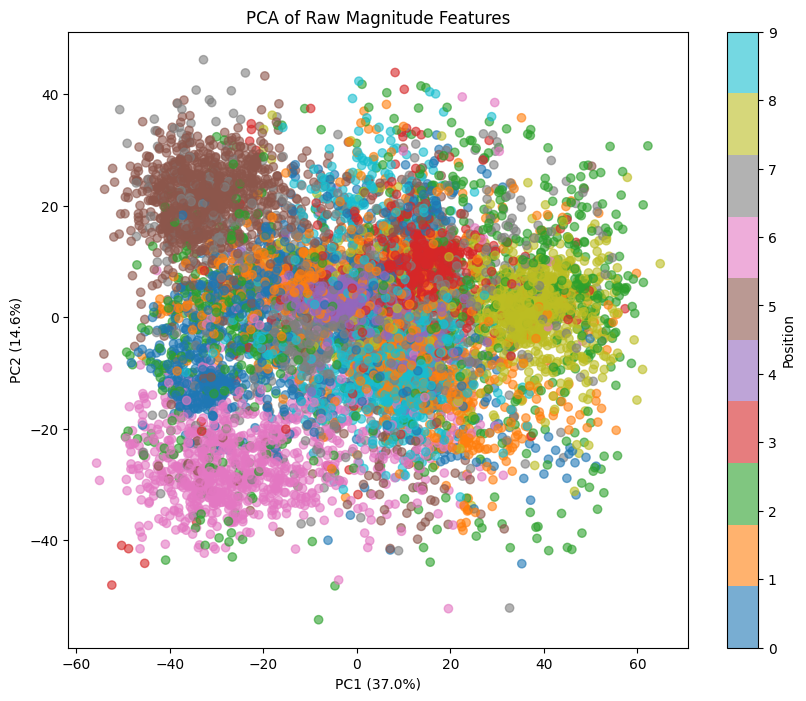

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Compare raw magnitude features vs. engineered features
raw_mag = [col for col in X_train.columns if col.startswith('mag')]
engineered = ['freq_ant1_spectral_energy', 'freq_ant1_spectral_entropy', 
              'antenna_correlation', 'phase_consistency', 'amp_ant1_mean']

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train[raw_mag])
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='tab10', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA of Raw Magnitude Features')
plt.colorbar(scatter, label='Position')
plt.show()

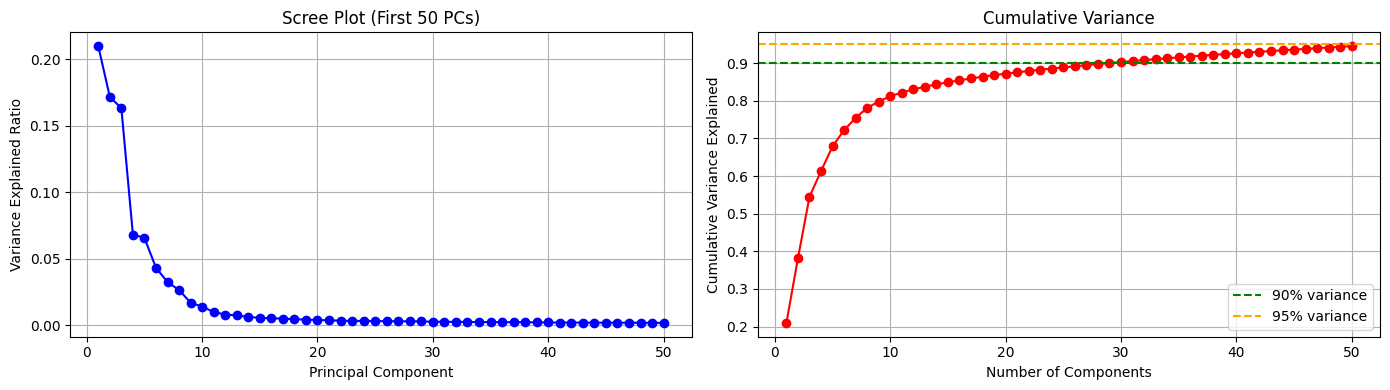

Variance explained by PC1: 20.99%
Variance explained by PC1+PC2: 38.17%
Components needed for 90% variance: 29
Components needed for 95% variance: 53
Total features: 146


In [108]:
from sklearn.decomposition import PCA
import numpy as np

scaler = RobustScaler()
X_train_scaled_robust = scaler.fit_transform(X_train)

# PCA on robust-scaled data
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled_robust)

# Cumulative variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

# Plot scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, 51), pca.explained_variance_ratio_[:50], 'bo-')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('Scree Plot (First 50 PCs)')
axes[0].grid()

axes[1].plot(range(1, 51), cumsum_var[:50], 'ro-')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# Print key stats
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC1+PC2: {cumsum_var[1]:.2%}")
print(f"Components needed for 90% variance: {np.argmax(cumsum_var >= 0.90) + 1}")
print(f"Components needed for 95% variance: {np.argmax(cumsum_var >= 0.95) + 1}")
print(f"Total features: {X_train_scaled_robust.shape[1]}")